In [3]:
# Instala os pacotes
# tidyverse, dplyr e readr são para manipular dados
#solitude possui o algoritimo de ML
#ggplot2 serve para visualização.
install.packages("tidyverse")
install.packages("dplyr")
install.packages("solitude")
install.packages("ggplot2")
install.packages("readr")

Warning message:
"package 'tidyverse' is in use and will not be installed"
Installing package into 'C:/Users/vitor/AppData/Local/R/win-library/4.2'
(as 'lib' is unspecified)

also installing the dependencies 'rlang', 'vctrs'





  There are binary versions available but the source versions are later:
      binary source needs_compilation
rlang  1.1.3  1.1.7              TRUE
vctrs  0.6.5  0.7.1              TRUE
dplyr  1.1.4  1.2.0              TRUE



installing the source packages 'rlang', 'vctrs', 'dplyr'


Warning message in install.packages("dplyr"):
"installation of package 'rlang' had non-zero exit status"
Warning message in install.packages("dplyr"):
"installation of package 'vctrs' had non-zero exit status"
Warning message in install.packages("dplyr"):
"installation of package 'dplyr' had non-zero exit status"
Installing package into 'C:/Users/vitor/AppData/Local/R/win-library/4.2'
(as 'lib' is unspecified)



package 'solitude' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\vitor\AppData\Local\Temp\Rtmpq8zuVs\downloaded_packages


Installing package into 'C:/Users/vitor/AppData/Local/R/win-library/4.2'
(as 'lib' is unspecified)




  There is a binary version available but the source version is later:
        binary source needs_compilation
ggplot2  3.5.1  4.0.2             FALSE



installing the source package 'ggplot2'


Installing package into 'C:/Users/vitor/AppData/Local/R/win-library/4.2'
(as 'lib' is unspecified)




  There is a binary version available but the source version is later:
      binary source needs_compilation
readr  2.1.5  2.2.0              TRUE



installing the source package 'readr'


Warning message in install.packages("readr"):
"installation of package 'readr' had non-zero exit status"


In [4]:
# Carrega os pacotes nesta sessão R
library(tidyverse)
library(dplyr)
library(solitude)
library(ggplot2)
library(readr)
library(future.apply)



Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Carregando pacotes exigidos: future



In [5]:
# Carrega os dados históricos
dados_historicos_dsa <- read_csv("dados_historicos.csv")
View(dados_historicos_dsa)

Rows: 650 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (2): transacao1, transacao2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


transacao1,transacao2
<dbl>,<dbl>
12.6692112,62.5871291
32.3547462,-21.4607156
-16.4932530,33.1128992
1.0421151,60.2179906
11.9590125,59.4238237
-32.7026268,79.1363808
37.2532251,0.8083048
-5.9687799,23.2903048
25.3030494,33.4427329


In [6]:
# Cria o modelo de Machine Learning com algoritmo isolationForest
?isolationForest 
modelo_ml_dsa = isolationForest$new() 

# Treina o modelo
modelo_ml_dsa$fit(dados_historicos_dsa)

# Faz as previsões com o modelo usando os dados históricos
previsoes_historico = dados_historicos_dsa %>%
  modelo_ml_dsa$predict() %>%
  arrange(desc(anomaly_score))

View(previsoes_historico)


INFO  [18:24:05.834] Building Isolation Forest ...
INFO  [18:24:07.023] done
INFO  [18:24:07.030] Computing depth of terminal nodes ...
INFO  [18:24:08.211] done
INFO  [18:24:08.292] Completed growing isolation forest


id,average_depth,anomaly_score
<int>,<dbl>,<dbl>
225,4.42,0.7415215
248,4.62,0.7315550
229,5.03,0.7115405
208,5.12,0.7072209
203,5.23,0.7019770
213,5.30,0.6986602
224,5.30,0.6986602
242,5.43,0.6925420
214,5.54,0.6874070


isolationForest            package:solitude            R Documentation

_F_i_t _a_n _I_s_o_l_a_t_i_o_n _F_o_r_e_s_t

_D_e_s_c_r_i_p_t_i_o_n:

     'solitude' class implements the isolation forest method introduced
     by paper Isolation based Anomaly Detection (Liu, Ting and Zhou
     <doi:10.1145/2133360.2133363>). The extremely randomized trees
     (extratrees) required to build the isolation forest is grown using
     'ranger' function from 'ranger' package.

_D_e_s_i_g_n:

     '$new()' initiates a new 'solitude' object. The possible arguments
     are:

        * 'sample_size': (positive integer, default = 256) Number of
          observations in the dataset to used to build a tree in the
          forest

        * 'num_trees': (positive integer, default = 100) Number of
          trees to be built in the forest

        * 'replace': (boolean, default = FALSE) Whether the sample of
          observations should be chosen with replacement whe

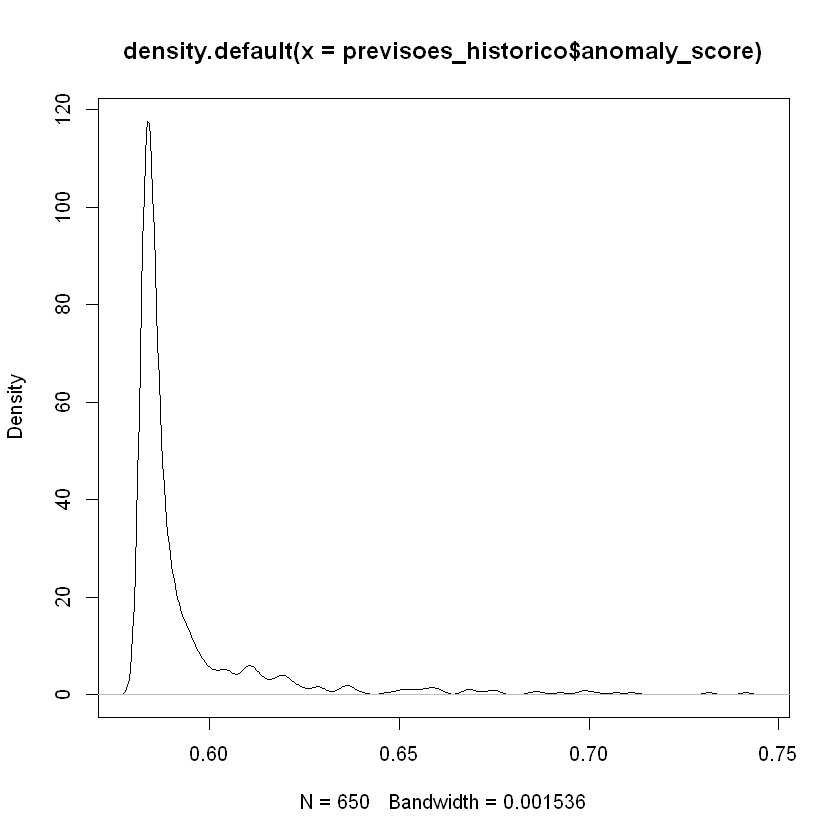

In [7]:
# Density Plot (histograma )
plot(density(previsoes_historico$anomaly_score))

# Quanto maior o anomaly score maior a chance do registro ser uma anomalia
# Vamos definir como regra que anomaly score acima de 0.62 é uma anomalia
indices_historico = previsoes_historico[which(previsoes_historico$anomaly_score > 0.62)]

# Faz o filtro
anomalias_historico = dados_historicos_dsa[indices_historico$id, ]
normais_historico = dados_historicos_dsa[-indices_historico$id, ]

[1] "white"                "aliceblue"            "antiquewhite"        
  [4] "antiquewhite1"        "antiquewhite2"        "antiquewhite3"       
  [7] "antiquewhite4"        "aquamarine"           "aquamarine1"         
 [10] "aquamarine2"          "aquamarine3"          "aquamarine4"         
 [13] "azure"                "azure1"               "azure2"              
 [16] "azure3"               "azure4"               "beige"               
 [19] "bisque"               "bisque1"              "bisque2"             
 [22] "bisque3"              "bisque4"              "black"               
 [25] "blanchedalmond"       "blue"                 "blue1"               
 [28] "blue2"                "blue3"                "blue4"               
 [31] "blueviolet"           "brown"                "brown1"              
 [34] "brown2"               "brown3"               "brown4"              
 [37] "burlywood"            "burlywood1"           "burlywood2"          
 [40] "burlywood3"           "burlywood4"           "cadetblue"           
 [43] "cadetblue1"           "cadetblue2"           "cadetblue3"          
 [46] "cadetblue4"           "chartreuse"           "chartreuse1"         
 [49] "chartreuse2"          "chartreuse3"          "chartreuse4"         
 [52] "chocolate"            "chocolate1"           "chocolate2"          
 [55] "chocolate3"           "chocolate4"           "coral"               
 [58] "coral1"               "coral2"               "coral3"              
 [61] "coral4"               "cornflowerblue"       "cornsilk"            
 [64] "cornsilk1"            "cornsilk2"            "cornsilk3"           
 [67] "cornsilk4"            "cyan"                 "cyan1"               
 [70] "cyan2"                "cyan3"                "cyan4"               
 [73] "darkblue"             "darkcyan"             "darkgoldenrod"       
 [76] "darkgoldenrod1"       "darkgoldenrod2"       "darkgoldenrod3"      
 [79] "darkgoldenrod4"       "darkgray"             "darkgreen"           
 [82] "darkgrey"             "darkkhaki"            "darkmagenta"         
 [85] "darkolivegreen"       "darkolivegreen1"      "darkolivegreen2"     
 [88] "darkolivegreen3"      "darkolivegreen4"      "darkorange"          
 [91] "darkorange1"          "darkorange2"          "darkorange3"         
 [94] "darkorange4"          "darkorchid"           "darkorchid1"         
 [97] "darkorchid2"          "darkorchid3"          "darkorchid4"         
[100] "darkred"              "darksalmon"           "darkseagreen"        
[103] "darkseagreen1"        "darkseagreen2"        "darkseagreen3"       
[106] "darkseagreen4"        "darkslateblue"        "darkslategray"       
[109] "darkslategray1"       "darkslategray2"       "darkslategray3"      
[112] "darkslategray4"       "darkslategrey"        "darkturquoise"       
[115] "darkviolet"           "deeppink"             "deeppink1"           
[118] "deeppink2"            "deeppink3"            "deeppink4"           
[121] "deepskyblue"          "deepskyblue1"         "deepskyblue2"        
[124] "deepskyblue3"         "deepskyblue4"         "dimgray"             
[127] "dimgrey"              "dodgerblue"           "dodgerblue1"         
[130] "dodgerblue2"          "dodgerblue3"          "dodgerblue4"         
[133] "firebrick"            "firebrick1"           "firebrick2"          
[136] "firebrick3"           "firebrick4"           "floralwhite"         
[139] "forestgreen"          "gainsboro"            "ghostwhite"          
[142] "gold"                 "gold1"                "gold2"               
[145] "gold3"                "gold4"                "goldenrod"           
[148] "goldenrod1"           "goldenrod2"           "goldenrod3"          
[151] "goldenrod4"           "gray"                 "gray0"               
[154] "gray1"                "gray2"                "gray3"               
[157] "gray4"                "gray5"                "gray6"               
[160] "gray7"              

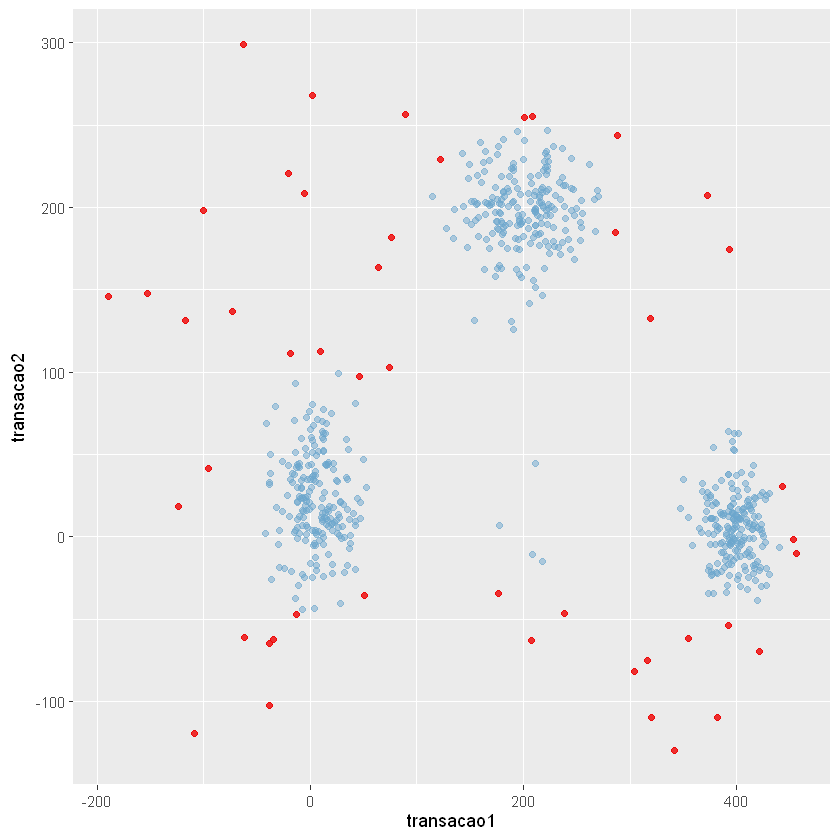

In [8]:
# Gráfico
colors()
ggplot() + 
  geom_point(data = normais_historico, 
             mapping = aes(transacao1,transacao2), 
             col = "skyblue3", 
             alpha = 0.5) + 
  geom_point(data = anomalias_historico,
             mapping = aes(transacao1,transacao2), 
             col = "red2", 
             alpha = 0.8)

In [9]:
# Novos dados
novos_dados_dsa <- read.csv("novos_dados.csv")
View(novos_dados_dsa)

transacao1,transacao2
<dbl>,<dbl>
17.976473,5.03836491
28.783271,37.67276673
11.975249,-28.47593937
15.911884,-10.19737749
5.488446,8.75253523
-1.855049,46.51708123
-63.718899,-1.20460606
10.971168,-11.98993336
-17.247205,-14.24794019


In [12]:
# Previsões com o modelo treinado
previsoes_novos_dados = modelo_ml_dsa$predict(novos_dados_dsa)

# Se o anomaly score é maior que 0.62 consideramos como anomalia
indices_novos_dados = previsoes_novos_dados[which(previsoes_novos_dados$anomaly_score > 0.62)]
View(indices_novos_dados)

id,average_depth,anomaly_score
<int>,<dbl>,<dbl>
7,6.84,0.6295280
48,6.66,0.6372416
57,6.70,0.6355193
65,6.95,0.6248601
153,7.02,0.6219077
172,6.98,0.6235931
174,7.02,0.6219077
194,6.99,0.6231713
253,6.91,0.6265535


In [14]:
#Criando uma tabela que criara relacionamento no power bi entre os dados da transação e à analise de anomalia, pelo id
novos_dados_dsa2 <- cbind(novos_dados_dsa, previsoes_novos_dados$id)

View(novos_dados_dsa2)

#Salvando a tabela para csv
write.csv(novos_dados_dsa2, "novos_dados_dsa2.csv")

transacao1,transacao2,previsoes_novos_dados$id
<dbl>,<dbl>,<int>
17.976473,5.03836491,1
28.783271,37.67276673,2
11.975249,-28.47593937,3
15.911884,-10.19737749,4
5.488446,8.75253523,5
-1.855049,46.51708123,6
-63.718899,-1.20460606,7
10.971168,-11.98993336,8
-17.247205,-14.24794019,9


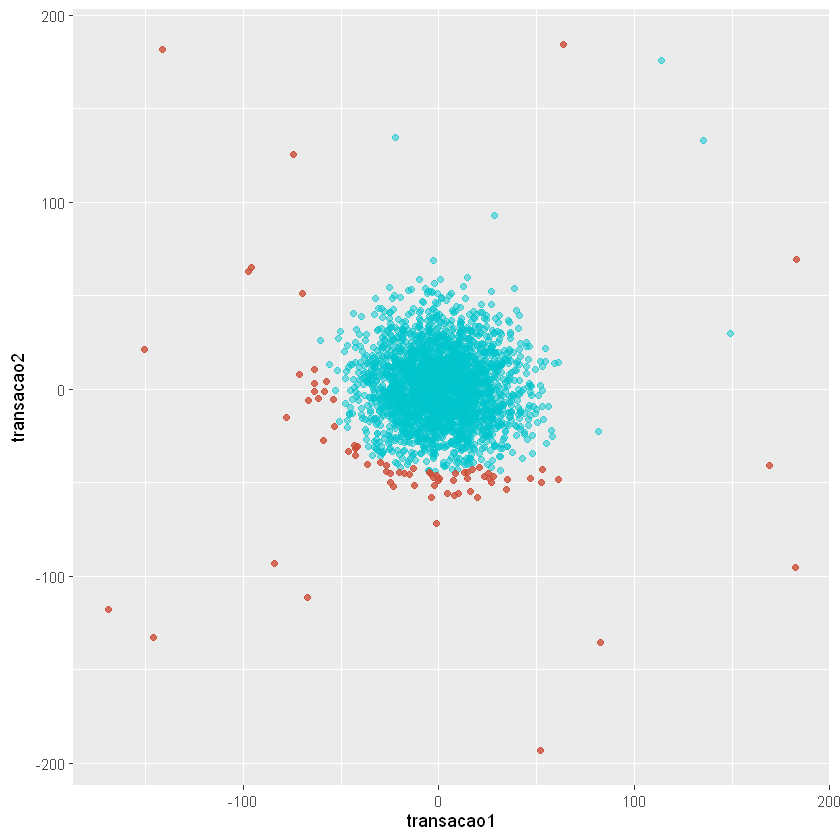

In [21]:
# Filtro
anomalias_novos_dados = novos_dados_dsa[indices_novos_dados$id, ]
normais_novos_dados = novos_dados_dsa[-indices_novos_dados$id, ]

# Gráfico das previsões
ggplot() + 
  geom_point(data = normais_novos_dados, 
             mapping = aes(transacao1,transacao2), 
             col = "turquoise3", 
             alpha = 0.5) + 
  geom_point(data = anomalias_novos_dados, 
             mapping = aes(transacao1,transacao2), 
             col = "tomato3", 
             alpha = 0.8)

In [22]:
# Arredondando a coluna 'anomaly_score' para 2 casas decimais
previsoes_novos_dados <- previsoes_novos_dados %>%
  mutate(anomaly_score = round(anomaly_score, 2))

# Criando uma nova coluna com base na condição
previsoes_novos_dados <- previsoes_novos_dados %>%
  mutate(status = ifelse(anomaly_score > 0.62, "Anomalia", "Normal"))

View(previsoes_novos_dados)


id,average_depth,anomaly_score,status
<int>,<dbl>,<dbl>,<chr>
1,7.95,0.58,Normal
2,7.98,0.58,Normal
3,7.59,0.60,Normal
4,7.76,0.59,Normal
5,8.00,0.58,Normal
6,7.94,0.58,Normal
7,6.84,0.63,Anomalia
8,7.91,0.59,Normal
9,7.83,0.59,Normal


Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's fill values."
Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's fill values."


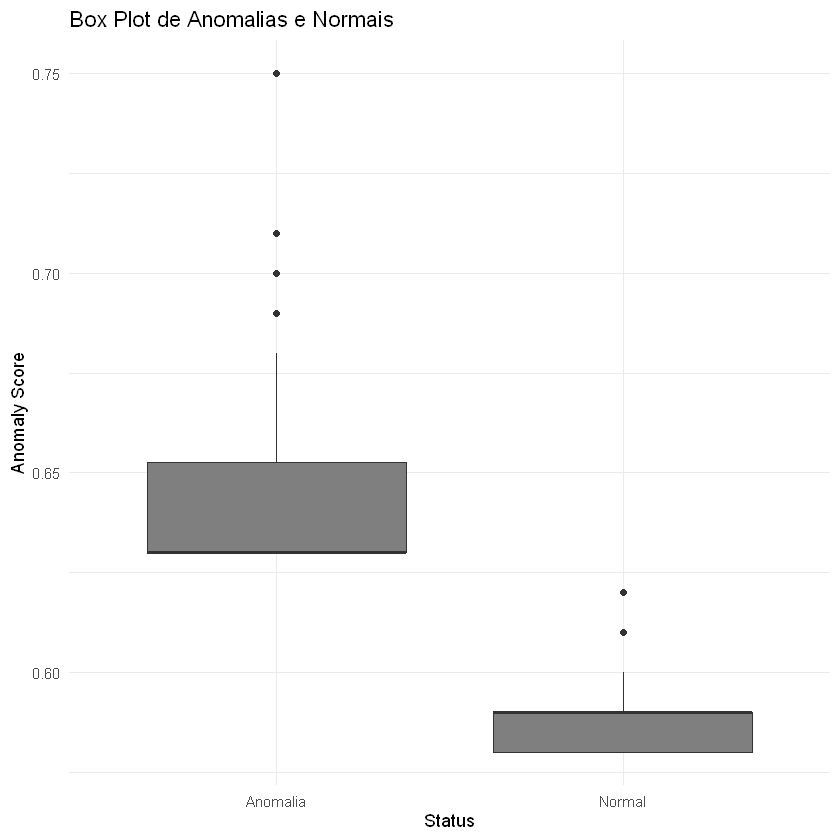

In [23]:
ggplot(previsoes_novos_dados, 
       aes(x = status, y = anomaly_score, fill = status)) +
  geom_boxplot() +
  labs(title = "Box Plot de Anomalias e Normais",
       x = "Status",
       y = "Anomaly Score") +
  theme_minimal() +
  scale_fill_manual(values = c("anomalia" = "red",
                               "normal" = "blue")) +
  theme(legend.position = "none")

In [24]:
# Salva em disco
write.csv(previsoes_novos_dados, "previsoes_novos_dados.csv")